# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
# importar librerías
import pandas as pd

In [2]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**: 

- El dataset no tiene valores ausentes.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [5]:
df['user_id'].describe()

count                                    40000
unique                                   40000
top       66bbd367-f5d7-456d-858c-7f0c21398285
freq                                         1
Name: user_id, dtype: object

 **Variable `date`**  
Explorar rango de fechas

In [6]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [7]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [8]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [9]:
# Resumen estadístico de usuarios que se convirtieron
df['converted'].value_counts()

0    34294
1     5706
Name: converted, dtype: int64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [10]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
for col in ['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']:
    print(f'Columna {col}')
    print(df[col].value_counts())
    print()    


Conteo de categorías:
Columna landing
B    20018
A    19982
Name: landing, dtype: int64

Columna region
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

Columna dispositivo
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

Columna traffic_source
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

Columna user_type
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64



✍️ **Comentario**: 
    
- `Todas las columnas tienen valores esperados.`

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [11]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

### Prueba t de student

**Hipótesis:**
- **Hipótesis nula (H₀):** `El gasto promedio de los clientes es igual en landing A y en landing B.`
- **Hipótesis alternativa (H₁):** `El gasto promedio de los clientes es diferente en landing A y landing B.`

In [12]:
# Aplicar prueba
from scipy.stats import ttest_ind


# Ejecutar prueba t y guardar resultados
t_stat, p_value = ttest_ind(gasto_A, gasto_B)


# Visualizar resultados
print(f"Estadístico : {t_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.36563589591332
Valor p: 1.0635288333792346e-20


### 📝 Conclusión e interpretación

**Decisión:**  
`Se rechaza la hipótesis nula`

**Interpretación de negocio:**  
En base a la prueba t realizada de 2 paginas independientes, tenemos un valor p (p_value) menor al umbral, entonces rechazamos la hipotesis nula, encontramos evidencia estadística en que el gasto promedio entre ambas paginas no es igual.

En promedio, los usuarios que convirtieron en la pagina B gastaron más que los de la pagina A.

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** `La tasa de conversiones es igual en ambas paginas.`
- **Hipótesis alternativa (H₁):** `La tasa de conversion es diferente en ambas paginas.`

In [13]:
# Número de usuarios convertidos por página
ususarios = df[df['converted'] == 1]
conversiones = ususarios.groupby('landing')['converted'].count()
# Total de usuarios por página
totales = df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [14]:
# Aplicar prueba
from statsmodels.stats.proportion import proportions_ztest

# Ejecutar prueba t y guardar resultados
z_stat, p_value = proportions_ztest(conversiones, totales)

# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22


In [15]:
tasa_A = conversiones[0] / totales[0]

In [16]:
tasa_B = conversiones[1] / totales[1]

print(f"Tasa de conversión página A: {tasa_A:.2%}")
print(f"Tasa de conversión página B: {tasa_B:.2%}")

Tasa de conversión página A: 12.57%
Tasa de conversión página B: 15.96%


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula

**Interpretación de negocio:**  
Tenemos un valor p (p_value) menor al umbral, encontramos evidencia estadística muy fuerte que la tasa de conversión difiere entre la Página A y la Página B. 
La Página A convirtió al 12.57% de sus usuarios, contra el 15.96% de la Página B.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** `La conversion es independiente de la fuente de trafico.`
- **Hipótesis alternativa (H₁):** `La conversion depende de la fuente de trafico.`

In [17]:
tabla = pd.crosstab(df['traffic_source'], df['converted'])
tabla

converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


In [18]:
tabla_normalizada = pd.crosstab(df['traffic_source'], df['converted'], normalize='index')*100
tabla_normalizada

converted,0,1
traffic_source,,
Ads,85.261835,14.738165
Email,85.007349,14.992651
Organic,86.212264,13.787736
Referral,86.118837,13.881163


In [19]:
# Aplicar prueba
from scipy.stats import chi2_contingency

chi2_stat, p_value, dof, expected = chi2_contingency(tabla)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)

Estadístico chi-cuadrado: 8.662
Valor P: 0.034
Grados de libertad: 3

Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula

**Interpretación de negocio:**  
Tenemos un valo p = 0.034 (p_value) por debajo del umbral, encontramos evidencia estadística (aunque no tan fuerte) de que la tasa de conversión difiere con la fuente de tráfico. Organic genera más conversiones porque recibe más tráfico, pero en términos de tasa, Email (14.99%) y Ads (14.74%) convierten mejor que Organic (13.79%) y Referral (13.88%).

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** `La conversion es independiente del tipo de usuario.`
- **Hipótesis alternativa (H₁):** `La conversion depende del tipo de usuario.`

In [20]:
tabla_1 = pd.crosstab(df['user_type'], df['converted'])
tabla_1

converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


In [21]:
tabla_1_normalizada = pd.crosstab(df['user_type'], df['converted'], normalize='index')*100
tabla_1_normalizada

converted,0,1
user_type,,
Nuevo,85.641301,14.358699
Recurrente,85.909644,14.090356


In [22]:
# Aplicar prueba

chi2_stat, p_value, dof, expected = chi2_contingency(tabla_1)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)

Estadístico chi-cuadrado: 0.513
Valor P: 0.474
Grados de libertad: 1

Frecuencias esperadas:
[[22319.39255  3713.60745]
 [11974.60745  1992.39255]]


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipótesis nula.

**Interpretación de negocio:**  
Con un valor p = 0.474 (p_value), mayor al umbral de 0.05, no encontramos evidencia estadística de que la tasa de conversión difiera entre usuarios nuevos (14.36%) y recurrentes (14.09%). Esto sugiere que la conversión podría ser independiente del tipo de usuario.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

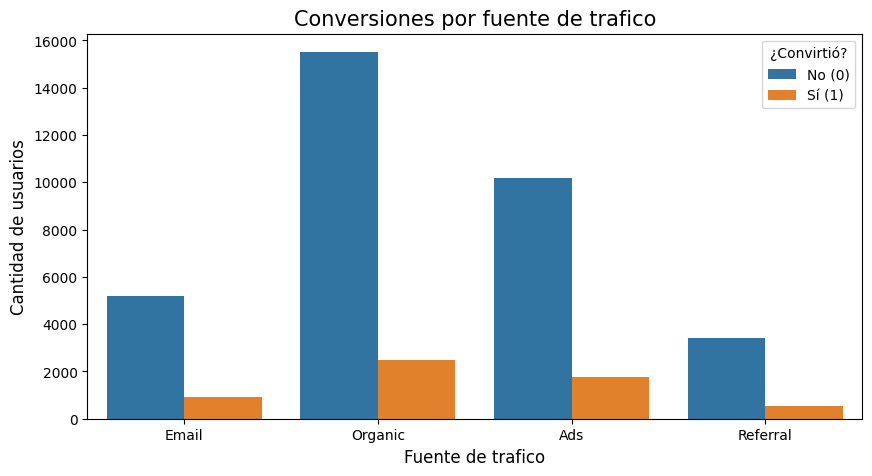

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Gráfico de barras agrupadas
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='traffic_source', hue='converted')
plt.title('Conversiones por fuente de trafico', fontsize=15)
plt.xlabel('Fuente de trafico', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

✍️ **Comentario**: 

El gráfico muestra la cantidad de usuarios que convirtieron (naranja) y que no convirtieron (azul) por cada fuente de tráfico. Organic domina ambas barras, generando más conversiones (2,480) que cualquier otra fuente.

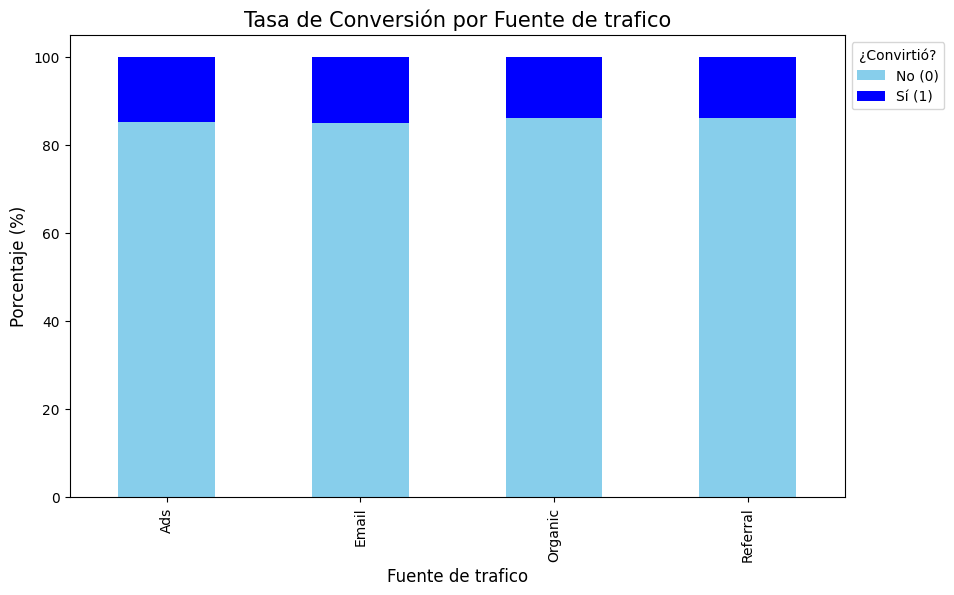

In [29]:
# Gráfico de barras apiladas
tabla_normalizada.plot(kind='bar', stacked=True, figsize=(10,6), color=['skyblue', 'blue'])

plt.title('Tasa de Conversión por Fuente de trafico', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Fuente de trafico', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

✍️ **Comentario**: 

Se aprecia que las cuatro barras se ven muy similares, ya que la diferencia entre la fuente con mejor y peor desempeño es de apenas 1.2 porciento. 


### Relación entre el tipo de usuario y la conversión

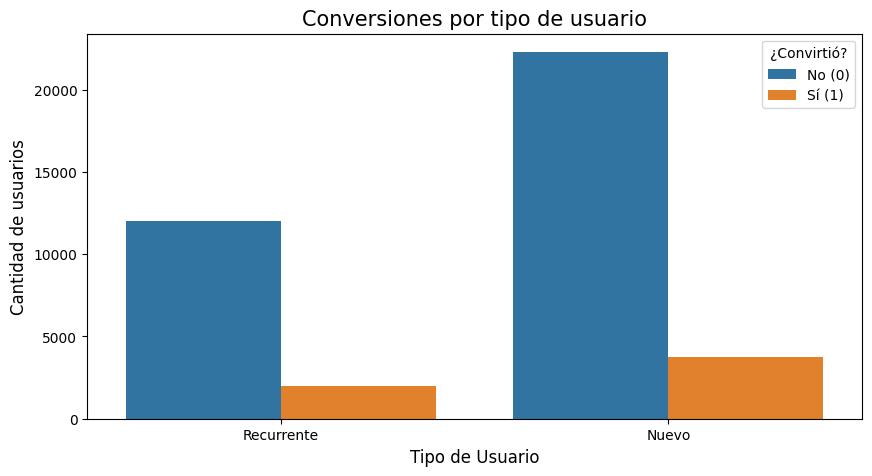

In [30]:
# Gráfico de barras agrupadas
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='user_type', hue='converted')
plt.title('Conversiones por tipo de usuario', fontsize=15)
plt.xlabel('Tipo de Usuario', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

✍️ **Comentario**: 

El gráfico muestra la cantidad de usuarios que convirtieron (naranja) y que no convirtieron (azul) por tipo de usuario. Los usuarios nuevos generan casi el doble de conversiones que los recurrentes.

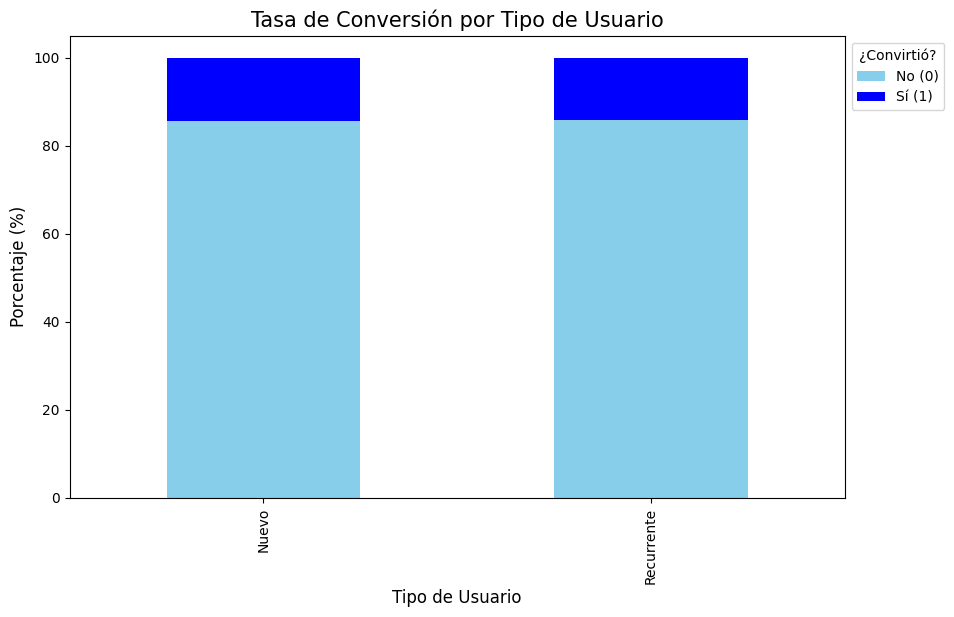

In [31]:
# Gráfico de barras apiladas
tabla_1_normalizada.plot(kind='bar', stacked=True, figsize=(10,6), color=['skyblue', 'blue'])

plt.title('Tasa de Conversión por Tipo de Usuario', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Tipo de Usuario', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

✍️ **Comentario**: 

Las dos barras son prácticamente iguales: la barra azul oscuro muestra conversión, es casi idéntica en ambos grupos.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders


Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?



---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- La Página A tiene un gasto promedio de 2,512, mientras que la Página B alcanza 3,194.
- Esta diferencia es estadísticamente muy significativa, por lo que no se explica por azar.
- **Interpretación:**
No solo hay más usuarios que gastan en la Página B, sino que quienes convierten ahí gastan más. 

**Tasa de conversión:** 
- La Página A convierte al 12.57% de sus usuarios, contra el 15.96% de la Página B.
- El resultado es estadísticamente significativo.
- **Interpretación:**
La Página B supera a la Página A tanto en volumen de conversión.
---

#### 📊 **Segmentación por fuente de tráfico**
- Las tasas de conversión varían ligermanete entre fuentes: Email (14.99%) y Ads (14.74%) convierten mejor que Referral (13.88%) y Organic (13.79%). La diferencia es estadísticamente significativa.
- **Interpretación:**
Organic aporta el mayor volumen de usuarios y conversiones en términos absolutos, pero no es la fuente más eficiente en tasa. Email y Ads, convierten proporcionalmente mejor. 
 ---

#### 📊 **Segmentación por tipo de usuario**
- Los usuarios nuevos convierten al 14.36% y los recurrentes al 14.09%.
- **Interpretación:**
El tipo de usuario no parece ser un factor que influya en la probabilidad de conversión. Esta segmentación no aporta valor.
---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 
- Migrar el tráfico hacia la Página B, dado que supera consistentemente a A tanto en tasa de conversión como en gasto promedio por usuario convertido, con evidencia estadística, en ambos casos.
- Priorizar inversión en Email y Ads sobre Organic y Referral, aunque la diferencia entre fuentes es pequeña, se debe evaluar costo por adquisición.